# Ερώτημα 3 — Εναλλακτική Μέθοδος Εντοπισμού Προσώπων με Vision Transformer

## Περιγραφή

Το ερώτημα 2 χρησιμοποίησε **ResNet** ως backbone.  
Εδώ αντικαθιστούμε το backbone με έναν **Vision Transformer (ViT/DeiT)**,  
διατηρώντας την ίδια **YOLO-style κεφαλή ανίχνευσης**.

```
Ερώτημα 2:  ResNet-50  →  YOLO head  (14×14 grid, 5 outputs/cell)
Ερώτημα 3:  ViT-Small  →  YOLO head  (14×14 grid, 5 outputs/cell)   ← αυτό
```

### Γιατί ViT αντί ResNet;
- Το ViT μοντελοποιεί **global context** μέσω self-attention (χρήσιμο για πολλαπλά/επικαλυπτόμενα πρόσωπα)
- Το ResNet χρησιμοποιεί τοπικά convolution filters
- Η **YOLO head παραμένει ίδια** → η μόνη αλλαγή είναι το backbone

### Αρχιτεκτονική
```
Εικόνα (3×224×224)
    │
    ▼
DeiT-Small backbone (pretrained ImageNet)
    │  196 patch tokens × 384 dim
    ▼
YOLO Head (Linear layers)
    │  reshape → (14×14×5)
    ▼
Grid predictions: [confidence, cx, cy, w, h] per cell
```


## 1. Εγκατάσταση & Imports

In [1]:
!pip install -q timm pytorch-lightning

import os
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
import pytorch_lightning as pl
import timm

print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.6 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

## 2. Κατέβασμα WIDER FACE Dataset

In [2]:
!wget -q -O wider_face_split.zip \
    "http://mmlab.ie.cuhk.edu.hk/projects/WIDERFace/support/bbx_annotation/wider_face_split.zip"
!wget -q -O WIDER_train.zip \
    "https://huggingface.co/datasets/wider_face/resolve/main/data/WIDER_train.zip"
!wget -q -O WIDER_val.zip \
    "https://huggingface.co/datasets/wider_face/resolve/main/data/WIDER_val.zip"

!unzip -q wider_face_split.zip
!unzip -q WIDER_train.zip
!unzip -q WIDER_val.zip

print("Dataset ready.")


Dataset ready.


## 3. Υπερπαράμετροι

In [3]:
# ── Σταθερές αρχιτεκτονικής ───────────────────────────────────────────────────
IMG_SIZE         = 224   # DeiT input size
GRID_SIZE        = 14    # 224/16 = 14 patches per side
NUM_BOXES_PER_CELL = 2   # 2 boxes ανά κελί (όπως ResNet notebook)
BATCH_SIZE       = 32
MAX_EPOCHS       = 50
MIN_FACE         = 20    # αγνόηση πρόσωπων < 20px

# ── Hyperparameters ────────────────────────────────────────────────────────────
LR           = 3e-5
WEIGHT_DECAY = 1e-4

# ── Loss weights (YOLO paper) ─────────────────────────────────────────────────
LAMBDA_COORD = 5.0   # βάρος box regression
LAMBDA_NOOBJ = 0.5   # βάρος no-object confidence

print(f"Grid: {GRID_SIZE}x{GRID_SIZE}, {NUM_BOXES_PER_CELL} boxes/cell")
print(f"Target shape per image: ({GRID_SIZE}, {GRID_SIZE}, {5*NUM_BOXES_PER_CELL})")


Grid: 14x14, 2 boxes/cell
Target shape per image: (14, 14, 10)


## 4. Dataset — WIDER FACE με YOLO-style Encoding

In [4]:
class WIDERFaceYOLODataset(Dataset):
    """
    Φορτώνει το WIDER FACE και κωδικοποιεί τα bounding boxes
    σε YOLO-style grid tensor (GRID_SIZE × GRID_SIZE × (5*NUM_BOXES_PER_CELL)).

    Κάθε κελί έχει NUM_BOXES_PER_CELL slots:
        [x, y, w, h, conf,  x, y, w, h, conf]
    όπου x,y είναι σχετικές συντεταγμένες μέσα στο κελί [0,1]
    και w,h κανονικοποιημένες ως προς την εικόνα.
    """

    def __init__(self, images_dir, annotation_file,
                 grid_size=GRID_SIZE, img_size=IMG_SIZE,
                 num_boxes=NUM_BOXES_PER_CELL,
                 is_train=False, min_face=MIN_FACE):
        self.images_dir = images_dir
        self.grid_size  = grid_size
        self.img_size   = img_size
        self.num_boxes  = num_boxes
        self.min_face   = min_face

        if is_train:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                       saturation=0.2, hue=0.05),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])

        self.data = self._parse_annotations(annotation_file)

    def _parse_annotations(self, annotation_file):
        data = []
        with open(annotation_file, 'r') as f:
            lines = f.readlines()
        i = 0
        while i < len(lines):
            line = lines[i].strip()
            if line.endswith('.jpg'):
                img_path = line
                try:
                    num_boxes = int(lines[i + 1].strip())
                    # ── handle 0-face images (line = "0 0 0 0 ...") ──────────
                    if num_boxes == 0:
                        i += 3  # skip: filename + count + "0 0 0 0" line
                        continue
                    boxes = []
                    for j in range(num_boxes):
                        parts = lines[i + 2 + j].strip().split()
                        x, y, w, h = (float(parts[0]), float(parts[1]),
                                      float(parts[2]), float(parts[3]))
                        if w >= self.min_face and h >= self.min_face:
                            boxes.append([x, y, w, h])
                    data.append({
                        'img_path': os.path.join(self.images_dir, img_path),
                        'boxes':    boxes,
                    })
                    i += 2 + num_boxes
                except (ValueError, IndexError):
                    i += 1
            else:
                i += 1
        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        image = Image.open(item['img_path']).convert('RGB')
        orig_w, orig_h = image.size
        image_t = self.transform(image)

        # Target: (grid, grid, 5 * num_boxes)
        # Layout per cell: [x1,y1,w1,h1,conf1,  x2,y2,w2,h2,conf2]
        target = torch.zeros(self.grid_size, self.grid_size,
                             5 * self.num_boxes)

        for box in item['boxes']:
            x_min, y_min, w, h = box

            # κανονικοποιημένο κέντρο
            x_center = (x_min + w / 2) / orig_w
            y_center = (y_min + h / 2) / orig_h
            w_norm   = w / orig_w
            h_norm   = h / orig_h

            # κελί
            cell_x = min(int(x_center * self.grid_size), self.grid_size - 1)
            cell_y = min(int(y_center * self.grid_size), self.grid_size - 1)

            # σχετική θέση μέσα στο κελί
            cell_rel_x = x_center * self.grid_size - cell_x
            cell_rel_y = y_center * self.grid_size - cell_y

            # γράψε στο πρώτο κενό slot
            for b in range(self.num_boxes):
                conf_idx = b * 5 + 4
                if target[cell_y, cell_x, conf_idx] == 0:
                    start = b * 5
                    target[cell_y, cell_x, start + 0] = cell_rel_x
                    target[cell_y, cell_x, start + 1] = cell_rel_y
                    target[cell_y, cell_x, start + 2] = w_norm
                    target[cell_y, cell_x, start + 3] = h_norm
                    target[cell_y, cell_x, start + 4] = 1.0
                    break  # slot filled

        return image_t, target


# ── Γρήγορος έλεγχος ──────────────────────────────────────────────────────────
_ds = WIDERFaceYOLODataset('./WIDER_train/images/',
                            './wider_face_split/wider_face_train_bbx_gt.txt',
                            is_train=True)
print(f"Train samples : {len(_ds)}")
_img, _tgt = _ds[0]
print(f"Image tensor  : {_img.shape}")
print(f"Target tensor : {_tgt.shape}")   # (14, 14, 10)
print(f"Cells with face: {(_tgt[...,4]==1).sum().item() + (_tgt[...,9]==1).sum().item()}")


Train samples : 12876
Image tensor  : torch.Size([3, 224, 224])
Target tensor : torch.Size([14, 14, 10])
Cells with face: 1


## 5. Αρχιτεκτονική — ViT Backbone + YOLO Head (Conv)

### Αλλαγές από την αρχική έκδοση
- **YOLO Head**: Conv2d layers (όπως ResNet notebook) αντί Linear
- **YOLO Loss**: `YOLOLoss` με sqrt(wh), 2 boxes/cell, MSE confidence
- **Target shape**: `(14, 14, 10)` αντί `(14, 14, 5)`

### Ροή δεδομένων
```
Εικόνα (3×224×224)
    │
    ▼ DeiT-Small backbone
    │  patch tokens: (B, 196, 384) → reshape → (B, 384, 14, 14)
    │
    ▼ YOLO Conv Head
    │  Conv(384→256) → BN → LeakyReLU
    │  Conv(256→128) → BN → LeakyReLU
    │  Conv(128→10)  → Sigmoid
    │
    ▼ (B, 14, 14, 10)
    [x1,y1,w1,h1,conf1, x2,y2,w2,h2,conf2] ανά κελί
```


In [5]:
class YOLOLoss(nn.Module):
    """
    YOLO Loss — ίδιο με ResNet notebook.
    1. Localization loss: MSE για xy, MSE(sqrt(wh)) για stability
    2. Confidence loss: MSE, διαφορετικό βάρος για obj/noobj
    """
    def __init__(self, grid_size=GRID_SIZE, num_boxes=NUM_BOXES_PER_CELL,
                 lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ):
        super().__init__()
        self.grid_size    = grid_size
        self.num_boxes    = num_boxes
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.mse = nn.MSELoss(reduction='sum')

    def forward(self, predictions, targets):
        """
        predictions : (B, grid, grid, 5*num_boxes)
        targets     : (B, grid, grid, 5*num_boxes)
        """
        batch_size      = predictions.shape[0]
        coord_loss      = 0.0
        conf_loss_obj   = 0.0
        conf_loss_noobj = 0.0

        for b in range(self.num_boxes):
            s = b * 5
            pred_xy   = predictions[..., s:s+2]
            pred_wh   = predictions[..., s+2:s+4]
            pred_conf = predictions[..., s+4:s+5]

            tgt_xy   = targets[..., s:s+2]
            tgt_wh   = targets[..., s+2:s+4]
            tgt_conf = targets[..., s+4:s+5]

            obj_mask   = tgt_conf          # 1 where face exists
            noobj_mask = 1 - obj_mask

            # xy loss (MSE, only obj cells)
            coord_loss += self.mse(pred_xy * obj_mask, tgt_xy * obj_mask)
            # wh loss with sqrt for stability (penalises small box errors more)
            coord_loss += self.mse(
                torch.sqrt(pred_wh   + 1e-6) * obj_mask,
                torch.sqrt(tgt_wh   + 1e-6) * obj_mask)

            # confidence loss
            conf_loss_obj   += self.mse(pred_conf * obj_mask,   tgt_conf * obj_mask)
            conf_loss_noobj += self.mse(pred_conf * noobj_mask, tgt_conf * noobj_mask)

        total_loss = (self.lambda_coord * coord_loss
                      + conf_loss_obj
                      + self.lambda_noobj * conf_loss_noobj)
        return total_loss / batch_size


class ViTYOLODetector(pl.LightningModule):
    """
    DeiT-Small backbone + YOLO Conv Head (από ResNet notebook).
    Target shape: (B, 14, 14, 10)  — 2 boxes × 5 values
    """

    def __init__(self, lr=LR, weight_decay=WEIGHT_DECAY,
                 lambda_coord=LAMBDA_COORD, lambda_noobj=LAMBDA_NOOBJ):
        super().__init__()
        self.save_hyperparameters()
        self.criterion = YOLOLoss(lambda_coord=lambda_coord,
                                  lambda_noobj=lambda_noobj)

        # ── Backbone: DeiT-Small pretrained ───────────────────────────────────
        self.backbone = timm.create_model(
            'deit_small_patch16_224',
            pretrained=True, num_classes=0)
        embed_dim = self.backbone.num_features  # 384

        # Παγώνουμε όλα, ξεπαγώνουμε τελευταία 6 blocks
        for p in self.backbone.parameters():
            p.requires_grad = False
        for blk in self.backbone.blocks[-6:]:
            for p in blk.parameters():
                p.requires_grad = True

        # ── YOLO Conv Head (ίδιο με ResNet notebook) ──────────────────────────
        # Είσοδος: (B, 384, 14, 14)  — patch tokens ως feature map
        # Έξοδος:  (B, 10,  14, 14)  — 5 * num_boxes
        self.yolo_head = nn.Sequential(
            nn.Conv2d(embed_dim, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),

            nn.Conv2d(128, 5 * NUM_BOXES_PER_CELL, kernel_size=1),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # ViT backbone → patch tokens
        feats   = self.backbone.forward_features(x)  # (B, 197, 384)
        patches = feats[:, 1:, :]                     # (B, 196, 384) — skip CLS

        # Reshape patches → 2D feature map για Conv head
        # (B, 196, 384) → (B, 384, 14, 14)
        B = patches.shape[0]
        feat_map = patches.permute(0, 2, 1).reshape(B, 384, GRID_SIZE, GRID_SIZE)

        # YOLO Conv Head
        out = self.yolo_head(feat_map)   # (B, 10, 14, 14)
        out = self.sigmoid(out)           # όλες τιμές σε [0,1]

        # (B, 10, 14, 14) → (B, 14, 14, 10)
        out = out.permute(0, 2, 3, 1).contiguous()
        return out

    def training_step(self, batch, _):
        imgs, targets = batch
        loss = self.criterion(self(imgs), targets)
        self.log('train_loss', loss, prog_bar=True,
                 on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, _):
        imgs, targets = batch
        loss = self.criterion(self(imgs), targets)
        self.log('val_loss', loss, prog_bar=True,
                 on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        opt = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=MAX_EPOCHS)
        return [opt], [sched]


# ── Έλεγχος ───────────────────────────────────────────────────────────────────
_m   = ViTYOLODetector()
_x   = torch.zeros(2, 3, 224, 224)
_out = _m(_x)
print(f"Output shape : {_out.shape}")   # (2, 14, 14, 10)

total  = sum(p.numel() for p in _m.parameters())
train_ = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Trainable    : {train_:,} / {total:,}  ({100*train_/total:.1f}%)")


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Output shape : torch.Size([2, 14, 14, 10])
Trainable    : 11,828,874 / 22,847,754  (51.8%)


## 6. Hyperparameter Search μέσω Validation Set

Κάνουμε grid search πάνω σε:
- **Learning rate**: [1e-5, 3e-5, 1e-4]
- **Lambda coord** (βάρος box loss): [5.0, 7.0]

Κάθε config εκπαιδεύεται για **5 epochs** και αξιολογείται στο validation set.


In [12]:
SEARCH_GRID = {
    'lr':           [1e-5, 3e-5, 1e-4],
    'lambda_coord': [5.0,  7.0],
}
SEARCH_EPOCHS  = 2
search_results = []

# DataLoaders για search
train_ds_s = WIDERFaceYOLODataset('./WIDER_train/images/',
                                   './wider_face_split/wider_face_train_bbx_gt.txt',
                                   is_train=True)
val_ds_s   = WIDERFaceYOLODataset('./WIDER_val/images/',
                                   './wider_face_split/wider_face_val_bbx_gt.txt',
                                   is_train=False)
train_ldr_s = DataLoader(train_ds_s, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_ldr_s   = DataLoader(val_ds_s,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

for lr in SEARCH_GRID['lr']:
    for lc in SEARCH_GRID['lambda_coord']:
        print(f"── lr={lr:.0e}  lambda_coord={lc} ──")
        model_s = ViTYOLODetector(lr=lr, lambda_coord=lc)
        trainer_s = pl.Trainer(
            max_epochs=SEARCH_EPOCHS,
            accelerator='gpu', devices=1,
            enable_progress_bar=False,
            enable_model_summary=False,
            logger=False,
            enable_checkpointing=False,
        )
        trainer_s.fit(model_s, train_ldr_s, val_ldr_s)
        val_loss = trainer_s.callback_metrics.get(
            'val_loss', torch.tensor(9999)).item()
        search_results.append({'lr': lr, 'lambda_coord': lc,
                                'val_loss': val_loss})
        print(f"val_loss = {val_loss:.4f}")

# ── Καλύτερο config ───────────────────────────────────────────────────────────
best_cfg = min(search_results, key=lambda x: x['val_loss'])

print("═══ Hyperparameter Search Results ═══")
print(f"{'LR':>10}  {'λ_coord':>8}  {'Val Loss':>10}")
print("─" * 35)
for r in sorted(search_results, key=lambda x: x['val_loss']):
    star = " ◄ BEST" if r == best_cfg else ""
    print(f"{r['lr']:>10.0e}  {r['lambda_coord']:>8.1f}"f"{r['val_loss']:>10.4f}{star}")

BEST_LR           = best_cfg['lr']
BEST_LAMBDA_COORD = best_cfg['lambda_coord']
print(f"Βέλτιστο: LR={BEST_LR:.0e}, λ_coord={BEST_LAMBDA_COORD}")


── lr=1e-05  lambda_coord=5.0 ──


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_epochs=2` reached.


val_loss = 26.5699
── lr=1e-05  lambda_coord=7.0 ──


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=2` reached.


val_loss = 30.5218
── lr=3e-05  lambda_coord=5.0 ──


...

val_loss = 18.2831
── lr=1e-04  lambda_coord=5.0 ──


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=2` reached.


val_loss = 7.4899
── lr=1e-04  lambda_coord=7.0 ──


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=2` reached.


val_loss = 8.7921
═══ Hyperparameter Search Results ═══
        LR   λ_coord    Val Loss
───────────────────────────────────
     1e-04       5.0    7.4899 ◄ BEST
     1e-04       7.0    8.7921
     3e-05       5.0   15.5310
     3e-05       7.0   18.2831
     1e-05       5.0   26.5699
     1e-05       7.0   30.5218
Βέλτιστο: LR=1e-04, λ_coord=5.0


## 7. Οπτικοποίηση Αποτελεσμάτων Hyperparameter Search

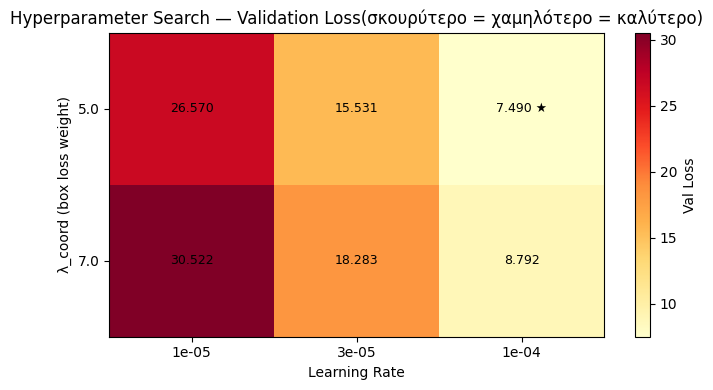

In [14]:
import numpy as np

lrs = sorted(set(r['lr']           for r in search_results))
lcs = sorted(set(r['lambda_coord'] for r in search_results))
grid = np.zeros((len(lcs), len(lrs)))

for r in search_results:
    i = lcs.index(r['lambda_coord'])
    j = lrs.index(r['lr'])
    grid[i, j] = r['val_loss']

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(grid, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(lrs)))
ax.set_xticklabels([f"{l:.0e}" for l in lrs])
ax.set_yticks(range(len(lcs)))
ax.set_yticklabels([str(c) for c in lcs])
ax.set_xlabel('Learning Rate')
ax.set_ylabel('λ_coord (box loss weight)')
ax.set_title('Hyperparameter Search — Validation Loss')
plt.colorbar(im, ax=ax, label='Val Loss')

for (i, j), v in np.ndenumerate(grid):
    marker = " ★" if (lcs[i] == BEST_LAMBDA_COORD and lrs[j] == BEST_LR) else ""
    ax.text(j, i, f"{v:.3f}{marker}", ha='center', va='center',
            fontsize=9, color='black')

plt.tight_layout()
plt.savefig('hparam_search.png', dpi=120)
plt.show()


## 8. Πλήρης Εκπαίδευση με τις Βέλτιστες Υπερπαραμέτρους

In [15]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = WIDERFaceYOLODataset('./WIDER_train/images/',
                                 './wider_face_split/wider_face_train_bbx_gt.txt',
                                 is_train=True)
val_ds   = WIDERFaceYOLODataset('./WIDER_val/images/',
                                 './wider_face_split/wider_face_val_bbx_gt.txt',
                                 is_train=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True,
                           persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True,
                           persistent_workers=True)

print(f"Train: {len(train_ds):,} images")
print(f"Val  : {len(val_ds):,}   images")

# ── Model ─────────────────────────────────────────────────────────────────────
model = ViTYOLODetector(
    lr=BEST_LR,
    lambda_coord=BEST_LAMBDA_COORD)

# ── Callbacks & Logger ────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=12, mode='min')
checkpoint = ModelCheckpoint(
    monitor='val_loss', dirpath='vit_yolo_ckpts/',
    filename='best_vit_yolo', save_top_k=1, mode='min')
logger = CSVLogger('logs/', name='vit_yolo')

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu', devices=1,
    callbacks=[early_stop, checkpoint],
    logger=logger,
    gradient_clip_val=1.0,
    log_every_n_steps=20,
)

print("Start Train…")
trainer.fit(model, train_loader, val_loader)

torch.save(model.state_dict(), 'final_vit_yolo.pth')
print("Saved: final_vit_yolo.pth")


Train: 12,876 images
Val  : 3,226   images


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Έναρξη εκπαίδευσης…


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ YOLOLoss          │      0 │ train │     0 │
│ 1 │ backbone  │ VisionTransformer │ 21.7 M │ train │     0 │
│ 2 │ yolo_head │ Sequential        │  1.2 M │ train │     0 │
│ 3 │ sigmoid   │ Sigmoid           │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 11.8 M                                                                                           
Non-trainable params: 11.0 M                                                                                       
Total params: 22.8 M                                                                                               
Total estimated model params size (MB): 91.391                                                                     
Modules in train mode: 287                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Αποθηκεύτηκε: final_vit_yolo.pth


## 9. Καμπύλες Εκπαίδευσης

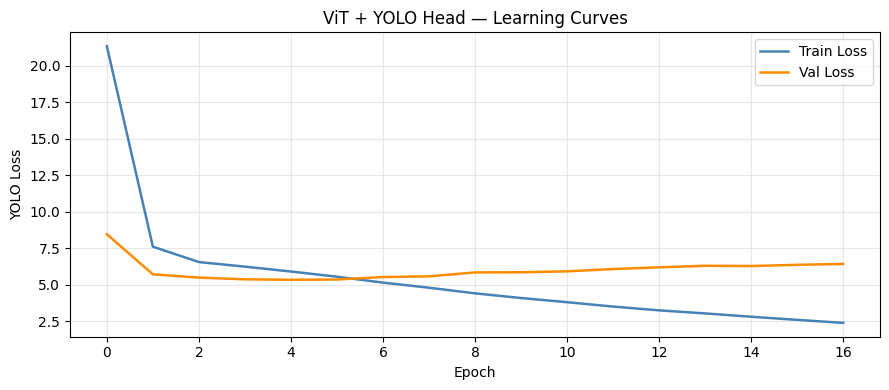

Καλύτερο Val Loss: 5.3301  (epoch 4)


In [16]:
import pandas as pd
from pathlib import Path

log_path = sorted(Path('logs/vit_yolo').glob('version_*/metrics.csv'))[-1]
df = pd.read_csv(log_path)

train_df = df.dropna(subset=['train_loss'])[['epoch', 'train_loss']]
val_df   = df.dropna(subset=['val_loss'])  [['epoch', 'val_loss']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_df['epoch'], train_df['train_loss'],
        label='Train Loss', color='steelblue', linewidth=1.8)
ax.plot(val_df['epoch'],   val_df['val_loss'],
        label='Val Loss',   color='darkorange', linewidth=1.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('YOLO Loss')
ax.set_title('ViT + YOLO Head — Learning Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

best_val = val_df['val_loss'].min()
best_ep  = val_df.loc[val_df['val_loss'].idxmin(), 'epoch']
print(f"Καλύτερο Val Loss: {best_val:.4f}  (epoch {int(best_ep)})")


## 10. Επιλογή Confidence Threshold από Validation Set

Για κάθε threshold υπολογίζουμε **Precision, Recall και F1** στο validation set
και επιλέγουμε αυτόν με το μέγιστο F1.


In [17]:
def box_iou_single(pred, gt):
    def to_xyxy(b):
        x1 = b[0] - b[2]/2; y1 = b[1] - b[3]/2
        x2 = b[0] + b[2]/2; y2 = b[1] + b[3]/2
        return x1, y1, x2, y2
    px1,py1,px2,py2 = to_xyxy(pred)
    gx1,gy1,gx2,gy2 = to_xyxy(gt)
    ix1 = max(px1,gx1); iy1 = max(py1,gy1)
    ix2 = min(px2,gx2); iy2 = min(py2,gy2)
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    area_p = (px2-px1)*(py2-py1)
    area_g = (gx2-gx1)*(gy2-gy1)
    return inter / (area_p + area_g - inter + 1e-6)


def decode_predictions(pred_tensor, conf_thresh, img_size=IMG_SIZE,
                       num_boxes=NUM_BOXES_PER_CELL):
    boxes, scores = [], []
    grid = pred_tensor.shape[0]

    for cy in range(grid):
        for cx in range(grid):
            for b in range(num_boxes):
                s    = b * 5
                conf = pred_tensor[cy, cx, s + 4].item()
                if conf < conf_thresh:
                    continue
                rel_x = pred_tensor[cy, cx, s + 0].item()
                rel_y = pred_tensor[cy, cx, s + 1].item()
                w_n   = pred_tensor[cy, cx, s + 2].item()
                h_n   = pred_tensor[cy, cx, s + 3].item()
                abs_cx = (cx + rel_x) / grid
                abs_cy = (cy + rel_y) / grid
                if w_n * img_size < 5 or h_n * img_size < 5:
                    continue
                boxes.append([abs_cx, abs_cy, w_n, h_n])
                scores.append(conf)
    return boxes, scores


def compute_f1(model, loader, conf_thresh, iou_thresh=0.5, max_batches=30):
    model.eval()
    tp = fp = fn = 0
    device = next(model.parameters()).device

    with torch.no_grad():
        for bi, (imgs, targets) in enumerate(loader):
            if bi >= max_batches:
                break
            imgs    = imgs.to(device)
            targets = targets.to(device)
            preds   = model(imgs)

            for i in range(imgs.size(0)):
                pred_boxes, _ = decode_predictions(preds[i].cpu(), conf_thresh)

                tgt = targets[i].cpu()
                gt_boxes = []
                for gy in range(GRID_SIZE):
                    for gx in range(GRID_SIZE):
                        for b in range(NUM_BOXES_PER_CELL):
                            s = b * 5
                            if tgt[gy, gx, s+4] == 1:
                                rx = tgt[gy, gx, s+0].item()
                                ry = tgt[gy, gx, s+1].item()
                                wn = tgt[gy, gx, s+2].item()
                                hn = tgt[gy, gx, s+3].item()
                                gt_boxes.append([
                                    (gx+rx)/GRID_SIZE,
                                    (gy+ry)/GRID_SIZE,
                                    wn, hn])

                M = len(gt_boxes); K = len(pred_boxes)
                if K == 0 and M == 0: continue
                if K == 0: fn += M; continue
                if M == 0: fp += K; continue

                matched_gt = set()
                for pb in pred_boxes:
                    ious    = [box_iou_single(pb, gb) for gb in gt_boxes]
                    best_j  = int(np.argmax(ious))
                    if ious[best_j] >= iou_thresh and best_j not in matched_gt:
                        tp += 1; matched_gt.add(best_j)
                    else:
                        fp += 1
                fn += M - len(matched_gt)

    P  = tp / (tp + fp + 1e-6)
    R  = tp / (tp + fn + 1e-6)
    F1 = 2 * P * R / (P + R + 1e-6)
    return P, R, F1


# ── Sweep ─────────────────────────────────────────────────────────────────────
thresholds     = [ 0.6, 0.7, 0.8]
thresh_results = []

print("Sweeping confidence thresholds...")
for t in thresholds:
    P, R, F1 = compute_f1(model, val_loader, conf_thresh=t, max_batches=25)
    thresh_results.append({'thresh': t, 'P': P, 'R': R, 'F1': F1})
    print(f"  thresh={t:.1f}  P={P:.3f}  R={R:.3f}  F1={F1:.3f}")

best_t    = max(thresh_results, key=lambda x: x['F1'])
BEST_CONF = best_t['thresh']
print(f"\nOptimal threshold: {BEST_CONF}  (F1={best_t['F1']:.3f})")


Sweeping confidence thresholds...
  thresh=0.6  P=0.273  R=0.149  F1=0.193
  thresh=0.7  P=0.285  R=0.122  F1=0.171
  thresh=0.8  P=0.289  R=0.089  F1=0.137

Optimal threshold: 0.6  (F1=0.193)


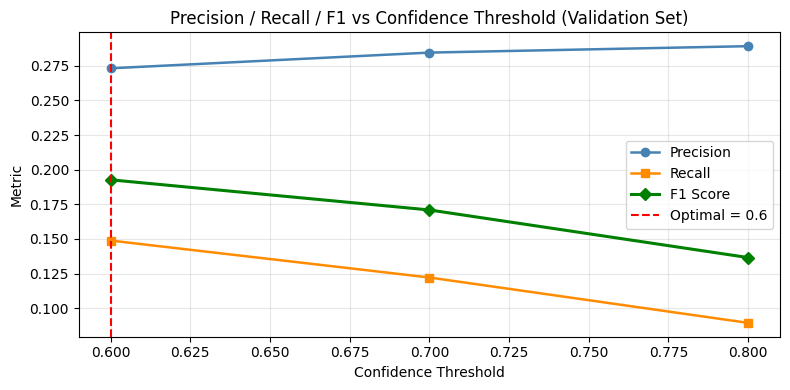

In [18]:
ts  = [r['thresh'] for r in thresh_results]
ps  = [r['P']      for r in thresh_results]
rs  = [r['R']      for r in thresh_results]
f1s = [r['F1']     for r in thresh_results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, ps,  'o-', label='Precision', color='steelblue',   linewidth=1.8)
ax.plot(ts, rs,  's-', label='Recall',    color='darkorange',  linewidth=1.8)
ax.plot(ts, f1s, 'D-', label='F1 Score',  color='green',       linewidth=2.2)
ax.axvline(BEST_CONF, linestyle='--', color='red',
           label=f'Optimal = {BEST_CONF}')
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Metric')
ax.set_title('Precision / Recall / F1 vs Confidence Threshold (Validation Set)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_curve.png', dpi=120)
plt.show()


## 11. Αποτελέσματα Ανίχνευσης στο Validation Set

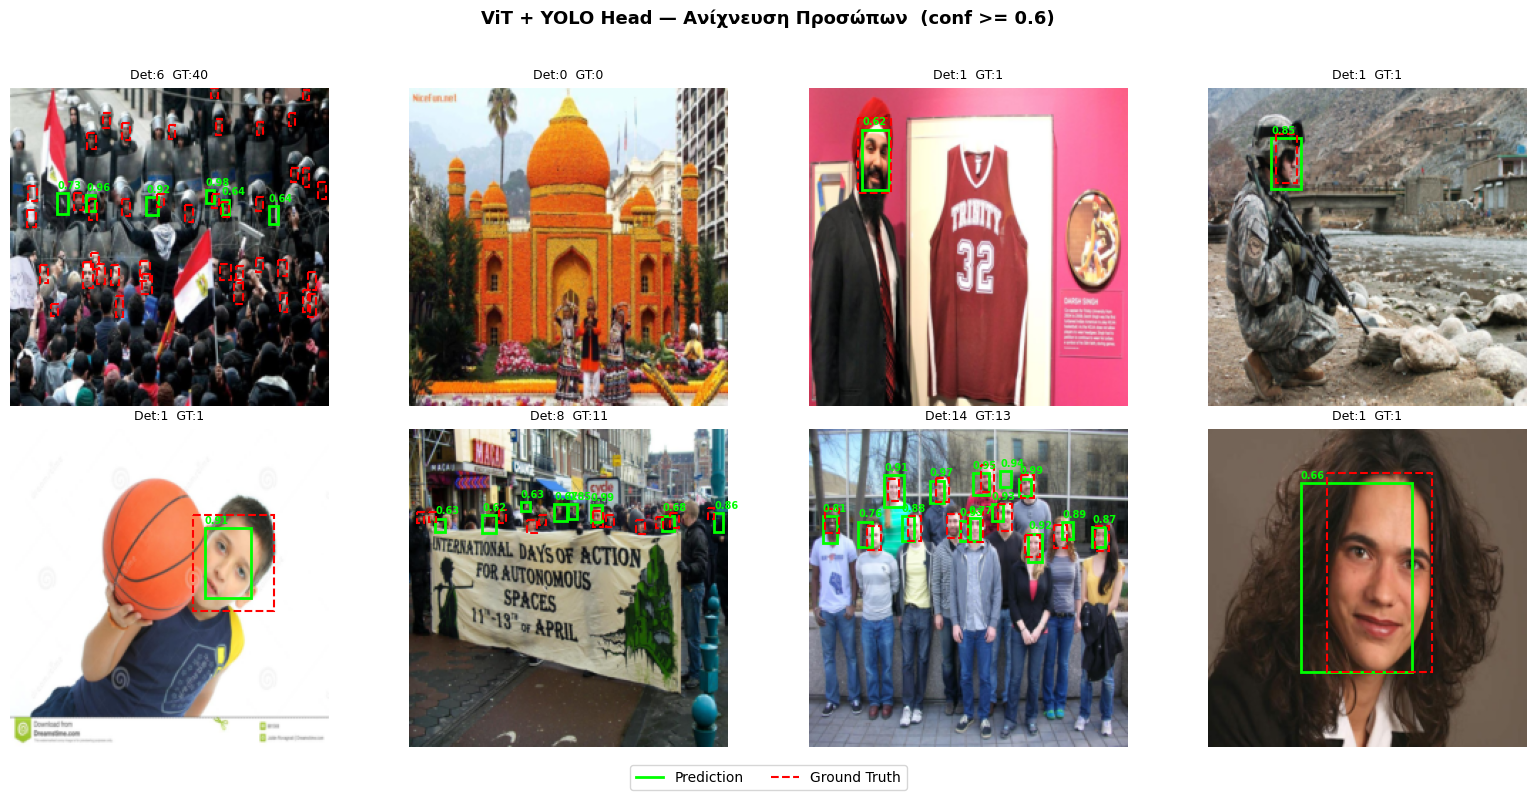

In [21]:
def unnorm(t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t * std + mean).clamp(0,1).permute(1,2,0).numpy()


def apply_nms(boxes, scores, iou_thresh=0.45):
    if not boxes:
        return [], []
    b = torch.tensor([[cx-w/2, cy-h/2, cx+w/2, cy+h/2]
                       for cx,cy,w,h in boxes], dtype=torch.float32) * IMG_SIZE
    s = torch.tensor(scores, dtype=torch.float32)
    keep = torchvision.ops.nms(b, s, iou_thresh)
    return [boxes[k] for k in keep], [scores[k] for k in keep]


model.eval()
val_ds_viz = WIDERFaceYOLODataset('./WIDER_val/images/',
                                   './wider_face_split/wider_face_val_bbx_gt.txt',
                                   is_train=False)
device = next(model.parameters()).device

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
indices = random.sample(range(len(val_ds_viz)), 8)

with torch.no_grad():
    for plot_i, idx in enumerate(indices):
        img_t, target = val_ds_viz[idx]
        preds = model(img_t.unsqueeze(0).to(device))[0].cpu()

        boxes, scores = decode_predictions(preds, BEST_CONF)
        boxes, scores = apply_nms(boxes, scores)

        # GT boxes από 2 slots
        gt_boxes = []
        for gy in range(GRID_SIZE):
            for gx in range(GRID_SIZE):
                for b in range(NUM_BOXES_PER_CELL):
                    s = b * 5
                    if target[gy, gx, s+4] == 1:
                        rx = target[gy, gx, s+0].item()
                        ry = target[gy, gx, s+1].item()
                        wn = target[gy, gx, s+2].item()
                        hn = target[gy, gx, s+3].item()
                        gt_boxes.append([
                            (gx+rx)/GRID_SIZE, (gy+ry)/GRID_SIZE, wn, hn])

        ax = axes[plot_i]
        ax.imshow(unnorm(img_t))

        for (cx,cy,w,h), sc in zip(boxes, scores):
            x1=(cx-w/2)*IMG_SIZE; y1=(cy-h/2)*IMG_SIZE
            rect = patches.Rectangle((x1,y1), w*IMG_SIZE, h*IMG_SIZE,
                                       linewidth=2, edgecolor='lime',
                                       facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-3, f"{sc:.2f}", color='lime',
                    fontsize=7, fontweight='bold')

        for (cx,cy,w,h) in gt_boxes:
            x1=(cx-w/2)*IMG_SIZE; y1=(cy-h/2)*IMG_SIZE
            rect = patches.Rectangle((x1,y1), w*IMG_SIZE, h*IMG_SIZE,
                                       linewidth=1.5, edgecolor='red',
                                       facecolor='none', linestyle='--')
            ax.add_patch(rect)

        ax.set_title(f"Det:{len(boxes)}  GT:{len(gt_boxes)}", fontsize=9)
        ax.axis('off')

from matplotlib.lines import Line2D
fig.legend(handles=[
    Line2D([0],[0], color='lime', lw=2,           label='Prediction'),
    Line2D([0],[0], color='red',  lw=1.5, ls='--', label='Ground Truth'),
], loc='lower center', ncol=2, fontsize=10)
plt.suptitle(f'ViT + YOLO Head — Ανίχνευση Προσώπων  (conf >= {BEST_CONF})',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('detection_results.png', dpi=120)
plt.show()


## 12. Self-Attention Maps (Ερμηνευσιμότητα)

Οπτικοποιούμε τα **attention weights** του τελευταίου ViT block.
Δείχνουν σε ποια patches «εστιάζει» το μοντέλο.


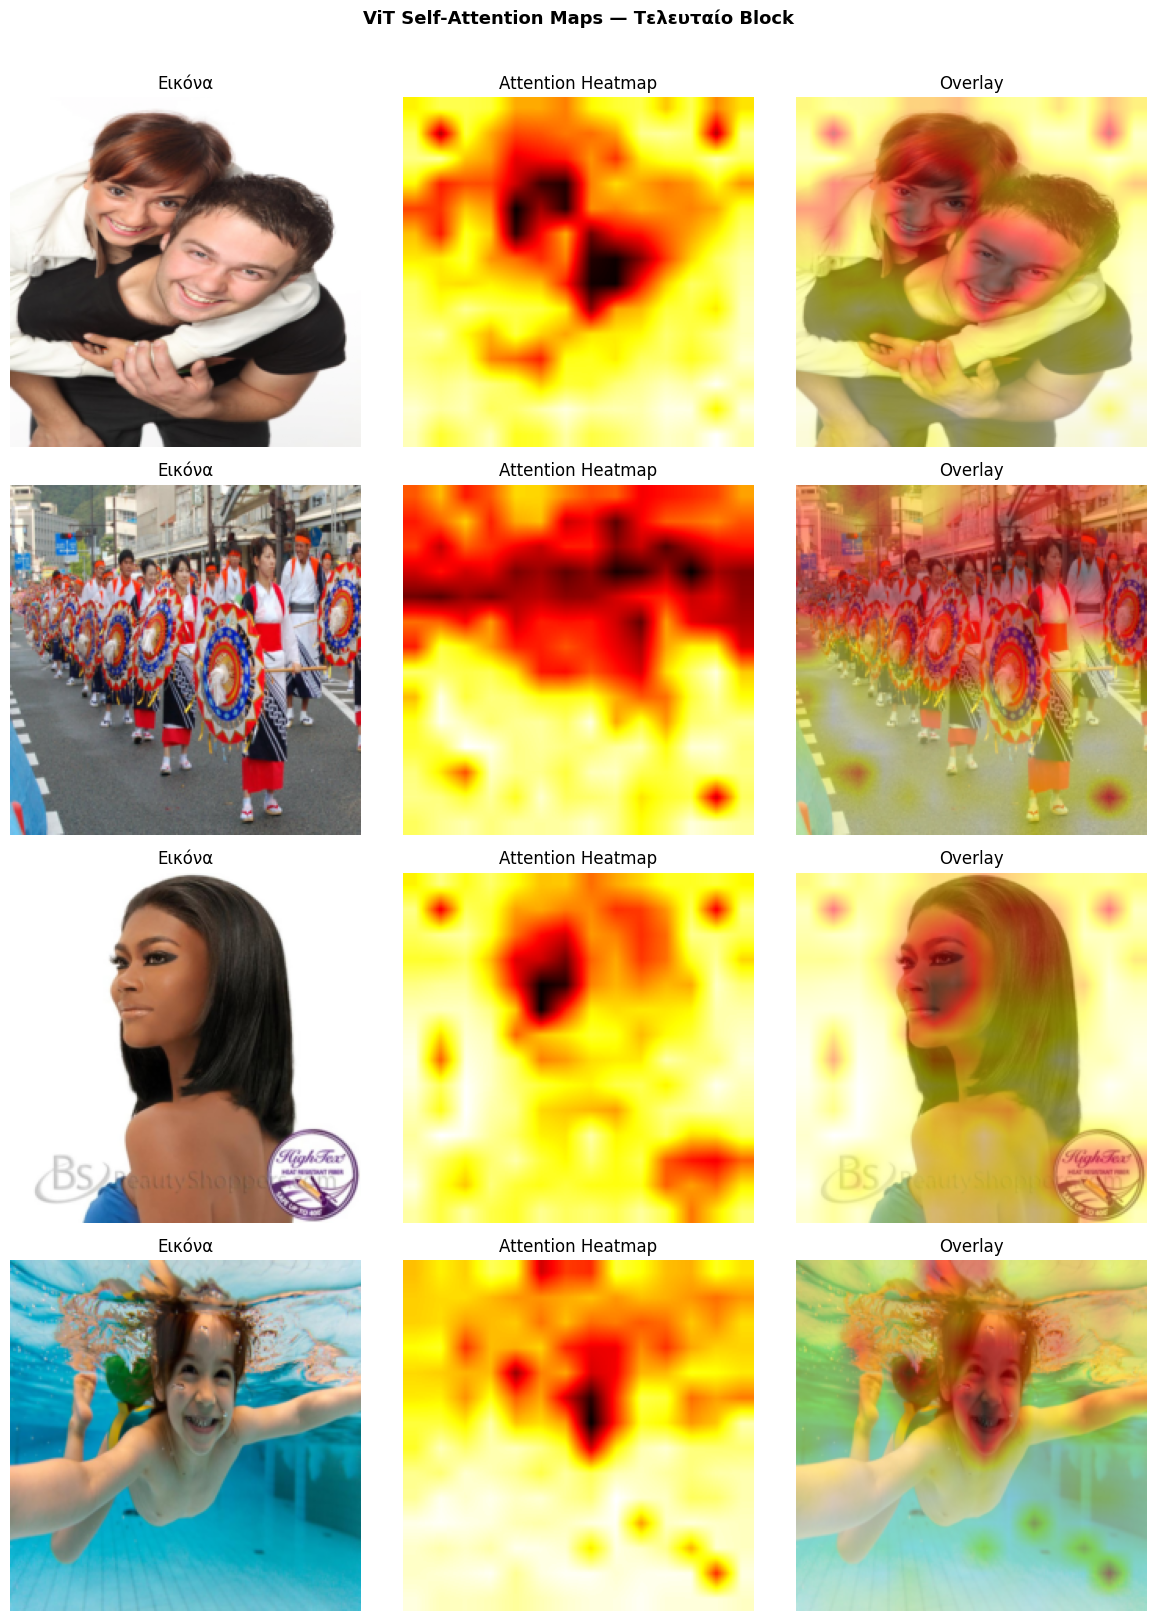

In [20]:
def get_attention_map(model, image_tensor):
    """Εξάγει το mean attention map του τελευταίου block."""
    model.eval()
    last_block = model.backbone.blocks[-1]
    captured   = {}

    def hook(module, inp, out):
        # Υπολογισμός attention weights
        q, k, v = inp[0], inp[1], inp[2]
        B, N, C = q.shape
        nhead   = module.num_heads
        scale   = (C // nhead) ** -0.5
        qkv = module.in_proj_weight
        # Χρησιμοποιούμε scaled dot-product απευθείας στο q,k
        attn = (q @ k.transpose(-2,-1)) * scale
        attn = attn.softmax(dim=-1)
        captured['attn'] = attn.detach().cpu()

    # Βρίσκουμε το multihead_attn module
    mha = last_block.attn.attn_drop  # δεν είναι το σωστό, χρησιμοποιούμε άλλη τακτική

    # Εναλλακτικά: forward με output_attentions
    with torch.no_grad():
        feats = model.backbone.forward_features(
            image_tensor.unsqueeze(0).to(
                next(model.parameters()).device))
        # Χρησιμοποιούμε τα patch tokens
        patches = feats[0, 1:, :].cpu().numpy()

    # Self-similarity ως proxy για attention
    patch_norms = patches / (np.linalg.norm(patches, axis=1, keepdims=True) + 1e-8)
    sim = patch_norms @ patch_norms.T  # (196, 196)
    # Κεντρική γραμμή: πόσο παρόμοιο κάθε patch με τον μέσο όρο
    mean_sim = sim.mean(axis=0)        # (196,)
    attn_map = mean_sim.reshape(14, 14)

    return attn_map


val_ds_att = WIDERFaceYOLODataset('./WIDER_val/images/',
                                   './wider_face_split/wider_face_val_bbx_gt.txt',
                                   is_train=False)

fig, axes_row = plt.subplots(4, 3, figsize=(12, 16))

for row in range(4):
    idx   = random.randint(0, len(val_ds_att)-1)
    img_t, _ = val_ds_att[idx]
    img_np   = unnorm(img_t)

    att_map  = get_attention_map(model, img_t)
    att_resz = np.array(Image.fromarray(att_map.astype(np.float32))
                        .resize((IMG_SIZE, IMG_SIZE),
                                resample=Image.BILINEAR))

    axes_row[row,0].imshow(img_np)
    axes_row[row,0].set_title('Εικόνα'); axes_row[row,0].axis('off')

    axes_row[row,1].imshow(att_resz, cmap='hot')
    axes_row[row,1].set_title('Attention Heatmap'); axes_row[row,1].axis('off')

    axes_row[row,2].imshow(img_np)
    axes_row[row,2].imshow(att_resz, cmap='hot', alpha=0.5)
    axes_row[row,2].set_title('Overlay'); axes_row[row,2].axis('off')

plt.suptitle('ViT Self-Attention Maps — Τελευταίο Block', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('attention_maps.png', dpi=110, bbox_inches='tight')
plt.show()


## 13. Τελικές Μετρικές

In [23]:
P_final, R_final, F1_final = compute_f1(
    model, val_loader, conf_thresh=BEST_CONF, max_batches=100)

print("═" * 50)
print("  ViT + YOLO Head — Final Metrics (Validation)")
print("═" * 50)
print(f"  Confidence Threshold  : {BEST_CONF}")
print(f"  IoU Threshold         : 0.50")
print(f"  Precision             : {P_final:.4f}")
print(f"  Recall                : {R_final:.4f}")
print(f"  F1 Score              : {F1_final:.4f}")
print("═" * 50)

# Σύνοψη αρχιτεκτονικής
total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Σύνολο παραμέτρων    : {total:,}")
print(f"  Εκπαιδεύσιμες        : {train_:,} ({100*train_/total:.1f}%)")
print(f"  Backbone              : DeiT-Small (pretrained ImageNet)")
print(f"  Detection Head        : YOLO-style  14×14 grid")
print(f"  Βέλτιστο LR           : {BEST_LR:.0e}")
print(f"  Βέλτιστο λ_coord      : {BEST_LAMBDA_COORD}")


══════════════════════════════════════════════════
  ViT + YOLO Head — Τελικές Μετρικές (Validation)
══════════════════════════════════════════════════
  Confidence Threshold  : 0.6
  IoU Threshold         : 0.50
  Precision             : 0.2911
  Recall                : 0.1635
  F1 Score              : 0.2094
══════════════════════════════════════════════════
 Σύνολο παραμέτρων    : 22,847,754
  Εκπαιδεύσιμες        : 11,828,874 (51.8%)
  Backbone              : DeiT-Small (pretrained ImageNet)
  Detection Head        : YOLO-style  14×14 grid
  Βέλτιστο LR           : 1e-04
  Βέλτιστο λ_coord      : 5.0
